In [2]:
import re
import numpy as np

In [3]:
nse_dict = {}

txtbook_path=r"F:\geodata\river_runoff_obs\note\note_2025-11-28_11-31-02_mon.txt"
with open(txtbook_path, 'r') as f:
    for line in f:
        if "NSE:" in line:
            name = line.split("|")[0].strip()
            nse = float(re.search(r"NSE:([-0-9.]+)", line).group(1))
            nse_dict.setdefault(name, []).append(nse)

for name, values in nse_dict.items():
    values = np.array(values)
    print(f"{name} -> Mean NSE: {values.mean():.3f} ± {values.std():.3f} (min={values.min():.3f}, max={values.max():.3f})")


1_hsg_imputMF_FGOALS-g3_ssp126_r1i1p1f1_mon -> Mean NSE: -0.310 ± 0.864 (min=-1.530, max=0.353)
1_hsg_imputMF_FGOALS-g3_ssp245_r1i1p1f1_mon -> Mean NSE: -0.119 ± 0.762 (min=-1.194, max=0.477)
1_hsg_imputMF_FGOALS-g3_ssp370_r1i1p1f1_mon -> Mean NSE: -0.221 ± 0.698 (min=-1.196, max=0.399)
1_hsg_imputMF_FGOALS-g3_ssp585_r1i1p1f1_mon -> Mean NSE: -0.067 ± 0.621 (min=-0.946, max=0.379)
2_dsk_imputMF_FGOALS-g3_ssp126_r1i1p1f1_mon -> Mean NSE: 0.550 ± 0.161 (min=0.403, max=0.774)
2_dsk_imputMF_FGOALS-g3_ssp245_r1i1p1f1_mon -> Mean NSE: 0.626 ± 0.123 (min=0.469, max=0.768)
2_dsk_imputMF_FGOALS-g3_ssp370_r1i1p1f1_mon -> Mean NSE: 0.630 ± 0.180 (min=0.383, max=0.805)
2_dsk_imputMF_FGOALS-g3_ssp585_r1i1p1f1_mon -> Mean NSE: 0.631 ± 0.127 (min=0.474, max=0.783)
3_xhl_imputMF_FGOALS-g3_ssp126_r1i1p1f1_mon -> Mean NSE: 0.807 ± 0.088 (min=0.689, max=0.899)
3_xhl_imputMF_FGOALS-g3_ssp245_r1i1p1f1_mon -> Mean NSE: 0.835 ± 0.061 (min=0.760, max=0.909)
3_xhl_imputMF_FGOALS-g3_ssp370_r1i1p1f1_mon -> Mean 

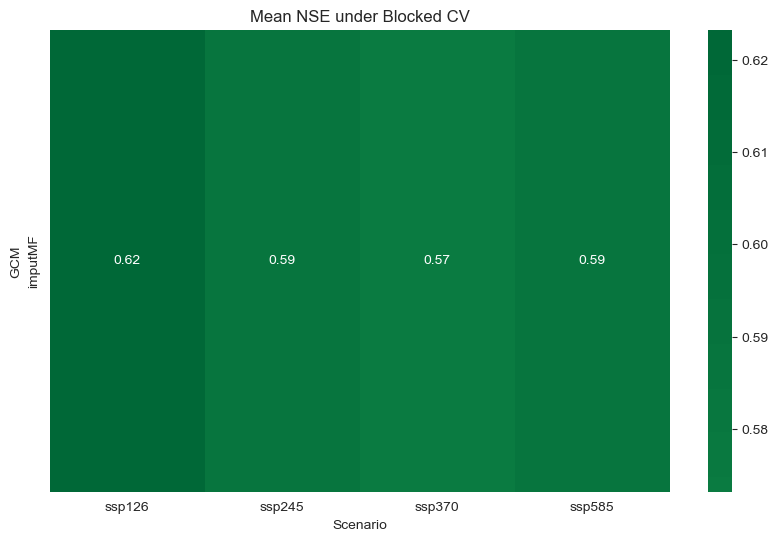

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

records = []

with open(txtbook_path, 'r') as f:
    for line in f:
        if "NSE:" in line:
            parts = line.split("|")
            name = parts[0].strip()
            scenario = parts[1].strip()
            gcm = name.split("_")[2]

            nse = float(line.split("NSE:")[1].split()[0])
            records.append([gcm, scenario, nse])

df_nse = pd.DataFrame(records, columns=["GCM", "Scenario", "NSE"])

pivot = df_nse.groupby(["GCM", "Scenario"])["NSE"].mean().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="RdYlGn", center=0)
plt.title("Mean NSE under Blocked CV")
plt.show()


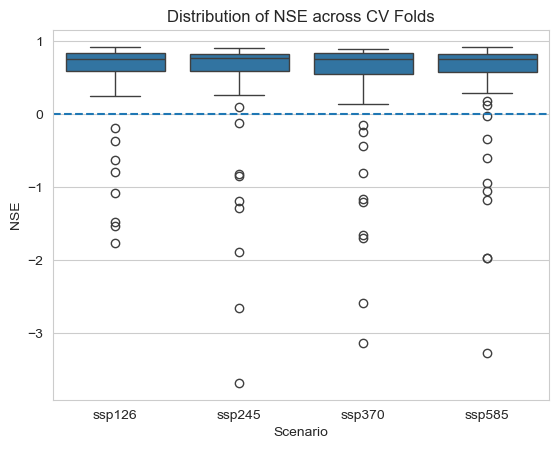

In [12]:
sns.boxplot(data=df_nse, x="Scenario", y="NSE")
plt.axhline(0, linestyle="--")
plt.title("Distribution of NSE across CV Folds")
# plt.ylim([0,1])
plt.show()


In [11]:
summary = df_nse.groupby("Scenario")["NSE"].agg(["mean","std","min","max"])
print(summary)


              mean       std     min     max
Scenario                                    
ssp126    0.623288  0.433322 -1.7627  0.9180
ssp245    0.588314  0.596024 -3.6822  0.9087
ssp370    0.573160  0.588073 -3.1382  0.8953
ssp585    0.585047  0.552116 -3.2767  0.9222


In [16]:
import pandas as pd
import re

records = []

with open(txtbook_path, 'r') as f:
    for line in f:
        if "NSE:" in line:
            parts = line.split("|")

            full_name = parts[0].strip()
            scenario = parts[1].strip()

            # Example: 1_hsg_imputMF_FGOALS-g3_ssp126_r1i1p1f1_mon
            station = full_name.split("_")[0]  # station id
            nse = float(re.search(r"NSE:([-0-9.]+)", line).group(1))

            records.append([station, scenario, nse])

df_nse = pd.DataFrame(records, columns=["Station", "Scenario", "NSE"])


In [17]:
pivot_station = df_nse.groupby(["Station", "Scenario"])["NSE"].mean().unstack()


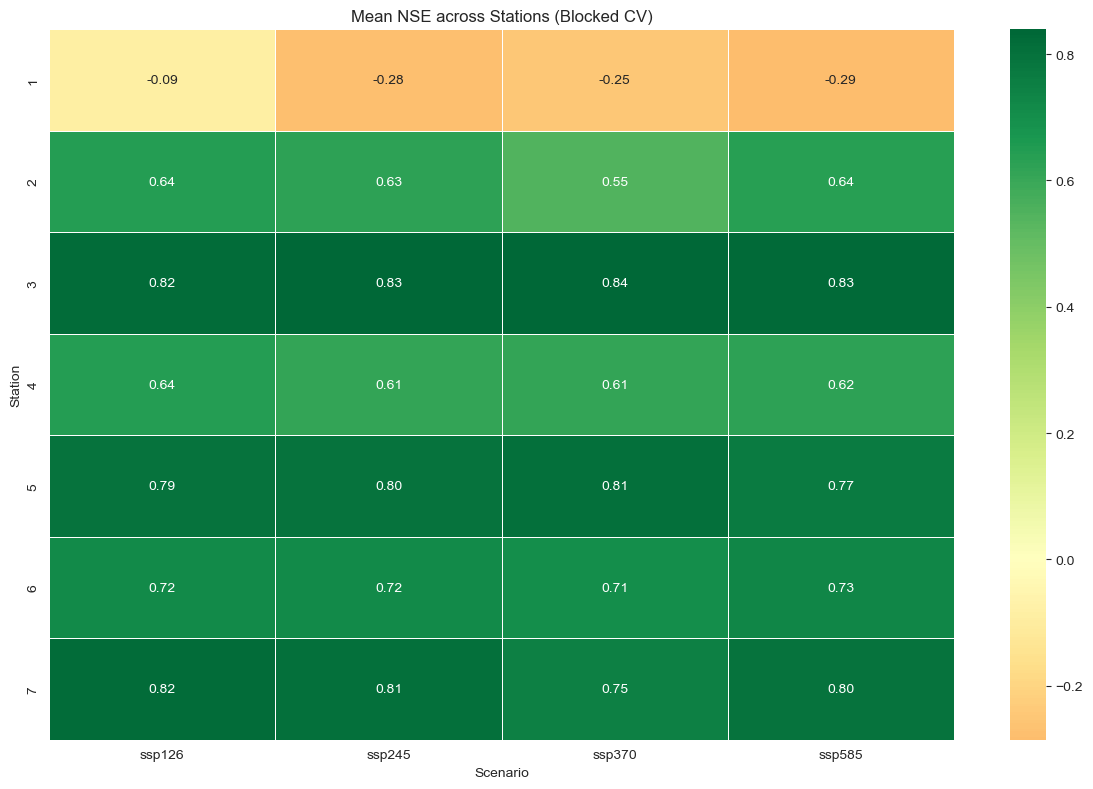

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_station,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5
)

plt.title("Mean NSE across Stations (Blocked CV)")
plt.xlabel("Scenario")
plt.ylabel("Station")
plt.tight_layout()
plt.show()


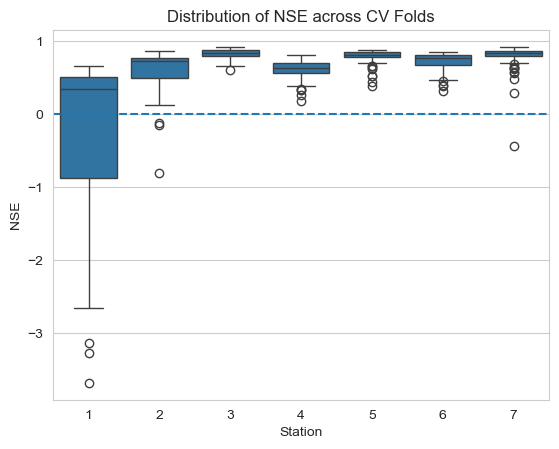

In [21]:
sns.boxplot(data=df_nse, x="Station", y="NSE")
plt.axhline(0, linestyle="--")
plt.title("Distribution of NSE across CV Folds")
# plt.ylim([0,1])
plt.show()